In [ ]:
import os

###Chemin vers les données
DATA_DIR = "C:\\Users\\user\\Desktop\\ISE2\\S2\\ML2\\projet_ml_2026\\Etudiant 1\\Projet-Groupe-18\\data"

####Liste les dossiers de classes disponibles
classes = os.listdir(DATA_DIR)
print("Classes trouvées :", classes)

#Comptons le nombre d'images pour chaque classe
for categorie in classes:
    chemin_classe = os.path.join(DATA_DIR, categorie)
    if os.path.isdir(chemin_classe):
        nb_images = len(os.listdir(chemin_classe))
        print(f"Catégorie {categorie} : {nb_images} images")

Classes trouvées : ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']
Catégorie cardboard : 403 images
Catégorie glass : 501 images
Catégorie metal : 410 images
Catégorie paper : 594 images


Catégorie plastic : 482 images
Catégorie trash : 137 images


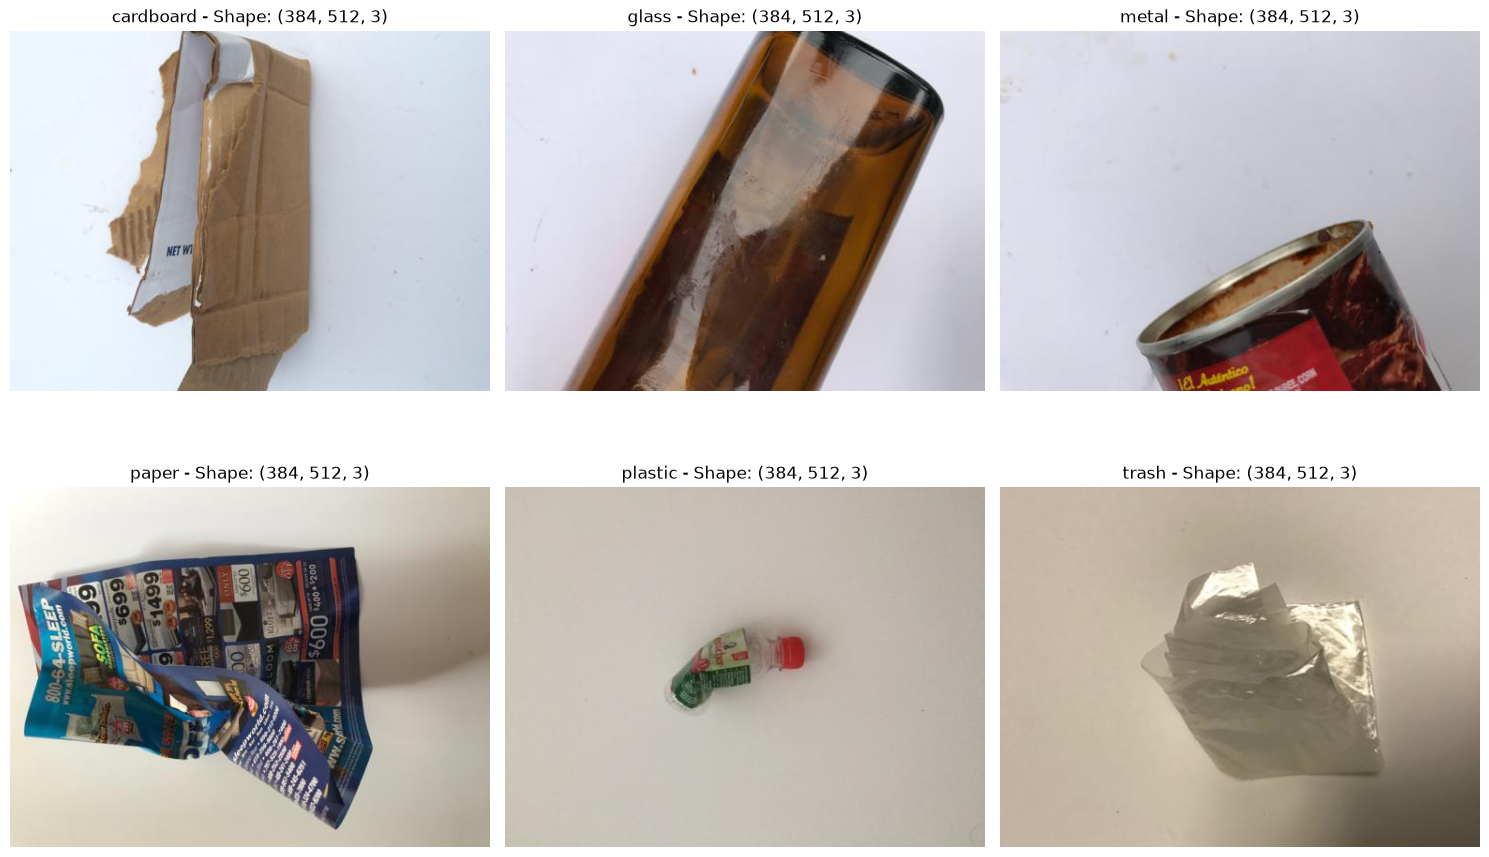

In [4]:
import cv2
import matplotlib.pyplot as plt
import random

# Visualisation d'un échantillon aléatoire par classe pour valider la qualité et les dimensions
plt.figure(figsize=(15, 10))

for i, categorie in enumerate(classes):
    chemin_classe = os.path.join(DATA_DIR, categorie)
    images = os.listdir(chemin_classe)
    
    # Sélection aléatoire d'une image dans la catégorie
    image_choisie = random.choice(images)
    chemin_image = os.path.join(chemin_classe, image_choisie)
    
    # Lecture de l'image et conversion du format BGR (OpenCV) en RGB (Matplotlib)
    img = cv2.imread(chemin_image)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    # Configuration de la grille d'affichage (2 lignes, 3 colonnes)
    plt.subplot(2, 3, i + 1)
    plt.imshow(img)
    plt.title(f"{categorie} - Shape: {img.shape}")
    plt.axis('off')

plt.tight_layout()
plt.show()

In [7]:
import tensorflow as tf

# Définition des hyperparamètres du pipeline
BATCH_SIZE = 32
IMG_HEIGHT = 300
IMG_WIDTH = 300
SEED = 42

# Création de l'ensemble d'entraînement
train_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,
    subset="training",
    seed=SEED,
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    label_mode='categorical'  # Nécessaire pour notre classification à 6 classes
)

# Création de l'ensemble de validation
val_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    label_mode='categorical'
)

# Optimisation des performances matérielles (CPU/GPU)
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

# Vérification des classes associées aux labels
class_names = train_ds.class_names
print("Classes chargées dans le pipeline :", class_names)

ModuleNotFoundError: No module named 'tensorflow.python'